<a href="https://colab.research.google.com/github/reehabjahangir3-coder/THzScattering/blob/main/THz_Mie_PSDInversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantification of scattering from particulates at THz frequencies

> This notebook is used to calculate theoretical scattering for non-absorbing, partially absorbing or perfectly conducting spheres at terahertz frequencies. Mie theory following Wiscombe's procedure is implemented into the pure python module developed by Scott Prahl called MiePython.

> https://onlinelibrary.wiley.com/doi/10.1002/andp.19083300302
> https://opensky.ucar.edu/islandora/object/technotes:232


> Miepython provides functions for calculating the extinction efficiency, scattering efficiency, backscattering, and scattering asymmetry. Angular scattering can also be calculated.


> https://miepython.readthedocs.io/en/2.5.5/index.html


In [ ]:
'''
Parameters to vary as needed
-Scattering Spectra - filename
-Material properties- medium and particle refractive index and absorption coefficient at THz frequencies
-Sample properties - volume fraction and sample thickness
-Vary Particle Size Distribution - define D10, D50 and D10
'''

'\nParameters to vary as needed\n-Scattering Spectra - filename\n-Material properties- medium and particle refractive index and absorption coefficient at THz frequencies\n-Sample properties - volume fraction and sample thickness\n-Vary Particle Size Distribution - define D10, D50 and D10\n'

In [ ]:
#import CSV files - Particle & Medium Properties, Scattering Loss Spectra
from google.colab import files

# This will open a file picker dialog for you to select your CSV file(s).
# Uploaded files will be stored in the current Colab runtime's file system.
# They will appear in the 'Files' tab on the left-hand panel.
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

# Example of how to read an uploaded CSV into a pandas DataFrame replace ('your_file.csv' with the actual uploaded filename)
# import pandas as pd
# df = pd.read_csv('your_file.csv')
# display(df.head())

Saving Alumina.csv to Alumina (6).csv
Saving C12_1x0.csv to C12_1x0.csv
Saving Paraffin.csv to Paraffin (6).csv
User uploaded file "Alumina (6).csv" with length 7254 bytes
User uploaded file "C12_1x0.csv" with length 846 bytes
User uploaded file "Paraffin (6).csv" with length 7247 bytes


In [ ]:
#install miepython package - https://miepython.readthedocs.io/en/latest/ by Scott Prahl
!pip install miepython

In [ ]:
#import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import miepython
from scipy.stats import lognorm
from scipy.optimize import minimize

In [ ]:
#Open the CSV file and convert THz to Hz and cm^-1 to m^-1
#Change file name here if needed
spec_df = pd.read_csv("C12_1x0.csv")

#Make sure file has the exact same column headings/copy paste the column headings here - otherwise it will throw up error
freqs = spec_df["Frequency_THz"].values * 1e12            # Hz
mu_s_meas = spec_df["Scattering Loss_cm^-1"].values * 100.0  # m^-1

idx = np.argsort(freqs)
freqs = freqs[idx]
mu_s_meas = mu_s_meas[idx]

In [ ]:
#DEFINE MATERIAL PROPERTIES -  THz optical properties

def load_material_properties(freqs_Hz):
    # Specify 'na_values' to treat '--' as NaN and convert columns to numeric
    alumina = pd.read_csv("Alumina.csv", na_values=["--"])
    paraffin = pd.read_csv("Paraffin.csv", na_values=["--"])

    f_al = alumina["Frequency_THz"].values * 1e12
    f_pa = paraffin["Frequency_THz"].values * 1e12

    # Ensure columns are numeric after handling NA values
    n_p = np.interp(freqs_Hz, f_al, alumina["Refractive Index"].astype(float).values)
    k_p = np.interp(freqs_Hz, f_al, alumina["Extinction Coefficient"].astype(float).values)
    n_m = np.interp(freqs_Hz, f_pa, paraffin["Refractive Index"].astype(float).values)

    m_rel = (n_p + 1j * k_p) / n_m
    return n_p, k_p, n_m, m_rel

n_p, k_p, n_m, m_freq = load_material_properties(freqs)

In [ ]:
#DEFINE SAMPLE PROPERTIES- Change volume fraction and thickness of sample accordingly

phi = 0.01       # volume fraction (%)
L = 0.00139        # sample thickness [m]

c = 3e8
wavelengths = c / freqs

In [ ]:
#Generate particle diameter grid, choose numbers that capture both smaller and bigger particle sizes
#Update accordingly for different P.S.D

D = np.logspace(np.log10(0.5e-6), np.log10(30e-6), 400)
r = D / 2

In [ ]:
#PARTICLE SIZE DISTRIBUTION (P.S.D)
#Change D10, D50 and D90 accordingly
#https://en.wikipedia.org/wiki/Log-normal_distribution

#This is the D50 value
D0_fixed = 2.5e-6

#Convert D10 and D20 values to lognormal width ≈ 1.19
sigma_g_fixed = np.log(17/0.4) / (2 * 1.2816)

#Documentation for lognormal function available on scipy

def lognormal_pdf(D):
    return lognorm.pdf(D, s=sigma_g_fixed, scale=D0_fixed)


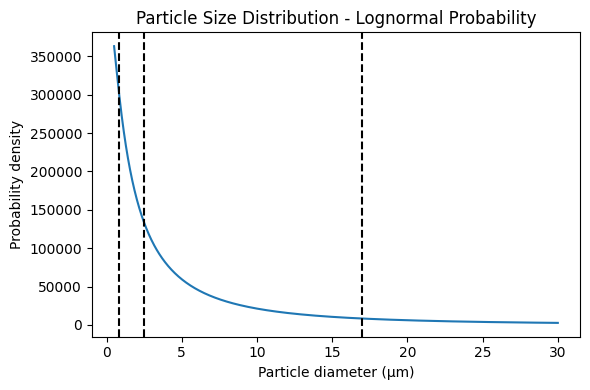

In [ ]:
#PLOT P.S.D
#Change P.S.D
Nd_plot = lognormal_pdf(D)
Nd_plot /= np.trapezoid(Nd_plot, D)

plt.figure(figsize=(6,4))
plt.plot(D*1e6, Nd_plot)
plt.axvline(0.8, ls='--', color='k')
plt.axvline(2.5, ls='--', color='k')
plt.axvline(17, ls='--', color='k')
plt.xlabel("Particle diameter (µm)")
plt.ylabel("Probability density")
plt.title("Particle Size Distribution - Lognormal Probability")
plt.tight_layout()
plt.show()

In [ ]:
#CALCULATE MIE SCATTERING CROSS SECTION ACCORDING TO MIEPYTHON PACKAGE

sigma = np.zeros((len(D), len(freqs)))

for i, ri in enumerate(r):
    d = 2.0 * ri  # diameter

#miepython.efficiencies is the correct function stored in the updated package
    for j, lam in enumerate(wavelengths):
        qext, qsca, qback, g = miepython.efficiencies(
            m_freq[j],
            d,
            lam,
            n_env=1.0
        )

        # Transport scattering cross section
        sigma[i, j] = qsca * (1.0 - g) * np.pi * ri**2

In [ ]:
#CONVERT SCATTERING CROSS SECTION INTO SCATTERING COEFFICIENT

def forward_model_alpha(alpha_ms):
  #Normalise the Particle Size Distribution
    Nd = lognormal_pdf(D)
    Nd /= np.trapezoid(Nd, D)

    # Enforce volume fraction
    moment3 = np.trapezoid(D**3 * Nd, D)
    N0 = 6.0 * phi / (np.pi * moment3)

    # Single scattering
    mu_single = np.zeros(len(freqs))
    for j in range(len(freqs)):
        mu_single[j] = N0 * np.trapezoid(Nd * sigma[:, j], D)

    # Multiple scattering correction
    mu_eff = mu_single * (1.0 + alpha_ms * mu_single * L)

    return mu_eff, mu_single

In [ ]:
# LEAST SQUARES FITTING OF MULTIPLE SCATTERING TO MEASURED SCATTERING

def loss_alpha(alpha_ms):
    if alpha_ms < 0.0 or alpha_ms > 3.0:
        return 1e12

    mu_pred, _ = forward_model_alpha(alpha_ms)
    return np.sum((mu_pred - mu_s_meas)**2)

In [ ]:
#NUMERICALLY MINIMISE LOSS FUNCION
result = minimize(
    loss_alpha,
    x0=1.0,
    bounds=[(0.0, 2.0)],
    method="L-BFGS-B"
)

alpha_ms_fit = result.x
mu_fit, mu_single = forward_model_alpha(alpha_ms_fit)

In [ ]:
print("===================================")
print(" FINAL THz SCATTERING RESULTS")
print("===================================")
print("Locked PSD:")
print("  D10 = 0.8 µm")
print("  D50 = 2.5 µm")
print("  D90 = 17 µm")
print(f"sigma_g = {sigma_g_fixed:.2f}")
print(f"Volume fraction φ = {phi:.3f}")
print(f"Fitted α_ms = {alpha_ms_fit[0]:.3f}")

 FINAL THz SCATTERING RESULTS
Locked PSD:
  D10 = 0.8 µm
  D50 = 2.5 µm
  D90 = 17 µm
sigma_g = 1.46
Volume fraction φ = 0.010
Fitted α_ms = 0.000


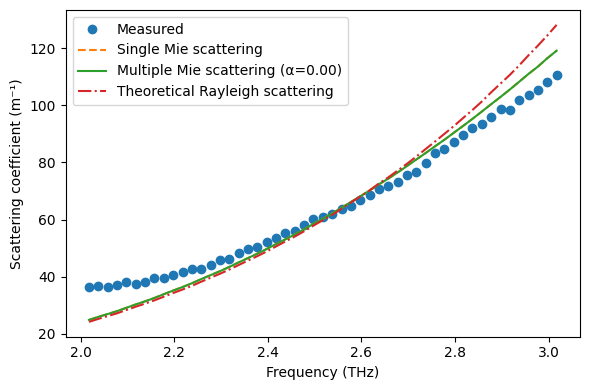

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(freqs/1e12, mu_s_meas, 'o', label="Measured")
plt.plot(freqs/1e12, mu_single, '--', label="Single Mie scattering")
plt.plot(freqs/1e12, mu_fit, '-', label=f"Multiple Mie scattering (α={alpha_ms_fit[0]:.2f})")
plt.plot(freqs/1e12, mu_rayleigh, '-.', label="Theoretical Rayleigh scattering")
plt.xlabel("Frequency (THz)")
plt.ylabel("Scattering coefficient (m⁻¹)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#ENHANCEMENT - MULTIPLE SCATTERING

#enhancement = 1 + alpha_ms_fit * mu_single * L

#plt.figure()
#plt.plot(freqs/1e12, enhancement)
#plt.xlabel("Frequency (THz)")
#plt.ylabel("Enhancement factor")
#plt.title("Multiple Scattering Enhancement")
#plt.show()

In [ ]:
# Best-fit chi^2
chi2_min = loss_alpha(alpha_ms_fit)

# Scan alpha around the best fit
alpha_grid = np.linspace(
    max(0.0, alpha_ms_fit - 1.0),
    alpha_ms_fit + 1.0,
    200
)

chi2_vals = np.array([loss_alpha(a) for a in alpha_grid])

In [ ]:
# 1-sigma threshold
chi2_threshold = chi2_min + 1.0

# Indices where chi2 crosses threshold
valid = chi2_vals <= chi2_threshold

alpha_low = alpha_grid[valid][0]
alpha_high = alpha_grid[valid][-1]

print("===================================")
print(" α_ms UNCERTAINTY (Δχ² = 1)")
print("===================================")
print(f"alpha_ms = {alpha_ms_fit[0]:.3f}")
print(f"1σ interval: [{alpha_low[0]:.3f}, {alpha_high[0]:.3f}]")
print(f"± {0.5*(alpha_high[0] - alpha_low[0]):.3f}")

 α_ms UNCERTAINTY (Δχ² = 1)
alpha_ms = 0.000
1σ interval: [0.000, 0.000]
± 0.000


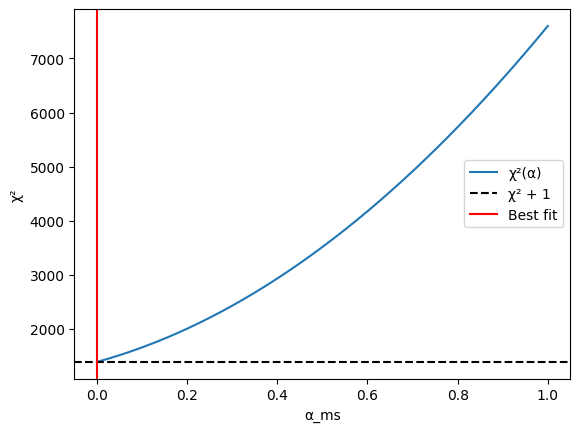

In [ ]:
plt.figure()
plt.plot(alpha_grid, chi2_vals, label="χ²(α)")
plt.axhline(chi2_threshold, ls='--', color='k', label="χ² + 1")
plt.axvline(alpha_ms_fit, color='r', label="Best fit")
plt.xlabel("α_ms")
plt.ylabel("χ²")
plt.legend()
plt.show()

In [ ]:
#CALCULATE THEORETICAL RAYLEIGH
def rayleigh_mu_s():
    # Locked PSD
    Nd = lognormal_pdf(D)
    Nd /= np.trapezoid(Nd, D)

    # Enforce volume fraction
    moment3 = np.trapezoid(D**3 * Nd, D)
    N0 = 6.0 * phi / (np.pi * moment3)

    mu_rayleigh = np.zeros(len(freqs))

    for j, lam in enumerate(wavelengths):
        sigma_r = rayleigh_sigma(r, lam, m_freq[j])
        mu_rayleigh[j] = N0 * np.trapezoid(Nd * sigma_r, D)

    return mu_rayleigh


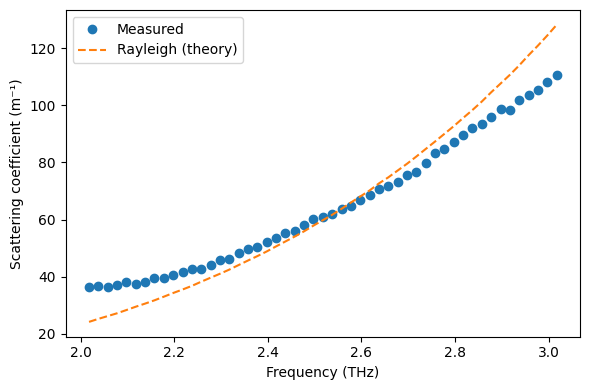

In [ ]:
#PLOT THEORETICAL RAYLEIGH VERSUS MEASURED RAYLEIGH

# Define the missing rayleigh_sigma function
def rayleigh_sigma(r, lam, m):
    """Calculates the Rayleigh scattering cross-section.
    r: particle radius
    lam: wavelength
    m: complex relative refractive index
    """
    term1 = (128 * np.pi**5 * r**6) / (3 * lam**4)
    term2 = np.abs((m**2 - 1) / (m**2 + 2))**2
    return term1 * term2

# Redefine rayleigh_mu_s to ensure it uses the rayleigh_sigma defined in this cell.
# This is necessary because the original rayleigh_mu_s was defined in a previous cell
# and would not see rayleigh_sigma defined here unless this cell re-executes
# rayleigh_mu_s after rayleigh_sigma.
def rayleigh_mu_s():
    Nd = lognormal_pdf(D)
    Nd /= np.trapezoid(Nd, D)
    moment3 = np.trapezoid(D**3 * Nd, D)
    N0 = 6.0 * phi / (np.pi * moment3)
    mu_rayleigh = np.zeros(len(freqs))
    for j, lam in enumerate(wavelengths):
        sigma_r = rayleigh_sigma(r, lam, m_freq[j])
        mu_rayleigh[j] = N0 * np.trapezoid(Nd * sigma_r, D)
    return mu_rayleigh

mu_rayleigh = rayleigh_mu_s()

plt.figure(figsize=(6,4))
plt.plot(freqs/1e12, mu_s_meas, 'o', label="Measured")
plt.plot(freqs/1e12, mu_rayleigh, '--', label="Rayleigh (theory)")
plt.xlabel("Frequency (THz)")
plt.ylabel("Scattering coefficient (m⁻¹)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Save and download results into a .csv file

data = {
    'Frequency (THz)': freqs / 1e12,
    'Measured Scattering (m^-1)': mu_s_meas,
    'Single Scattering (m^-1)': mu_single,
    'Mie Fit Scattering (m^-1)': mu_fit,
    'Theoretical Rayleigh Scattering (m^-1)': mu_rayleigh
}
df_results = pd.DataFrame(data)

# Save to CSV
output_filename = 'scattering_results.csv'
df_results.to_csv(output_filename, index=False)

print(f"Results saved to {output_filename}")

# Make the file downloadable
from google.colab import files
files.download(output_filename)

Results saved to scattering_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>